__EDA with Python and applying Logistic Regression__

Logistic Regression is a Machine Learning classification algorithm used to predict categories like:

° Yes / No

° True / False

° Survived / Not Survived

Real Titanic Example - Output - Survived or Not

Logistic Regression uses a special function __Sigmoid Function__

It converts any value into range: 0 to 1


In this TUT we will be working on [Titanic Dataset from Kaggle](https://www.kaggle.com/datasets/pankajvermacool/titanic-traincsv). This is a very famous dataset and very often is a student's first step in machine learning! 

We'll be trying to predict a classification-survival or deceased. Let's begin our understanding of implementing Logistic Regression in Python for classification.

__Import Libraries__

Let's import some libraries to get started!

In [457]:
# %matplotlib inline - “Show graphs directly below the code cell.” 

import pandas as pd  # to read the dataset and most of the preprocessing steps will be done using inbuilt functions inside pandas
import numpy as np  # to work with arrays
import matplotlib.pyplot as plt  # use for visualization 
import seaborn as sns  # use for visualization - statistical function
%matplotlib inline

__The Data__

Let's start by reading in the titanic_train.csv file into a pandas dataframe.

In [458]:
train = pd.read_csv('titanic_train.csv')

In [459]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


__Exploratory Data Analysis__

Let's begin some exploratory data analysis! We'll start by checking out missing data!

__Missing Data__

We can use seaborn to create a simple heatmap to see where we are missing data!

In [460]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

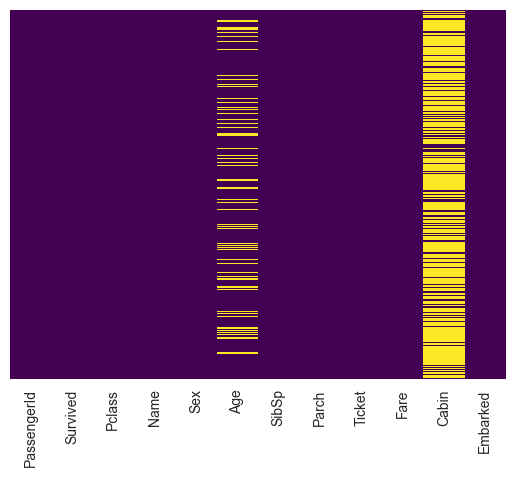

In [461]:
# cbar = density column
# cmap = color
# yticklabels = y axis data (ranging 0-800)
sns.heatmap(train.isnull(),yticklabels=False, cbar=False, cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

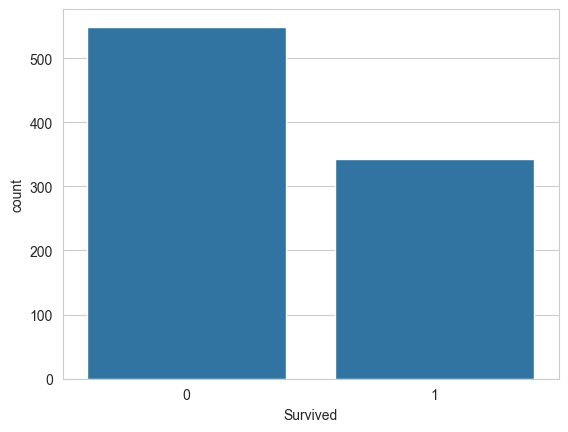

In [462]:
sns.set_style('whitegrid')
sns.countplot(data= train, x= 'Survived')

<Axes: xlabel='Survived', ylabel='count'>

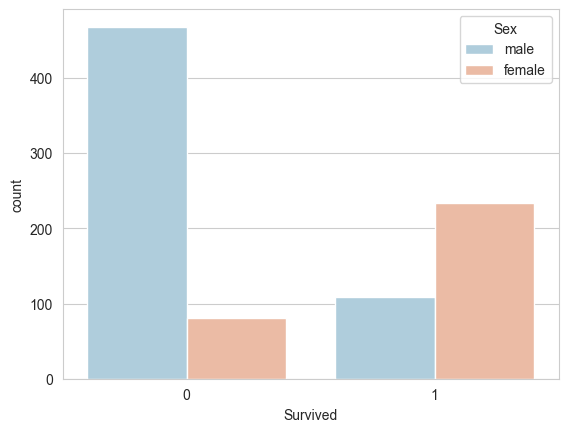

In [463]:
# palette = color

sns.set_style('whitegrid')
sns.countplot(data= train, x = 'Survived', hue = 'Sex', palette = 'RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

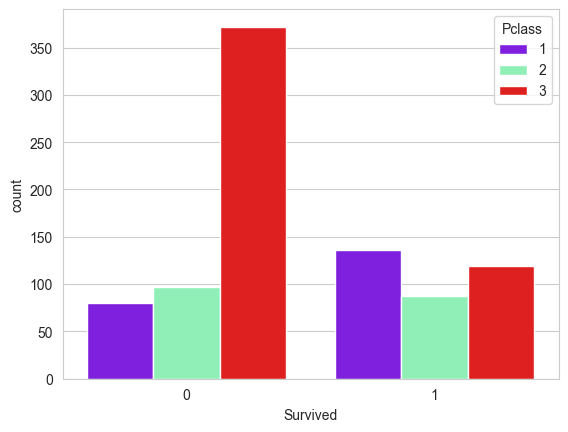

In [464]:
sns.set_style('whitegrid')
sns.countplot(data= train, x= 'Survived', hue = 'Pclass', palette = 'rainbow')

/var/folders/cn/wdc06fpx6v17849rk031ksx00000gn/T/ipykernel_4828/499549335.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde= False,color='darkred',bins=40)


<Axes: xlabel='Age'>

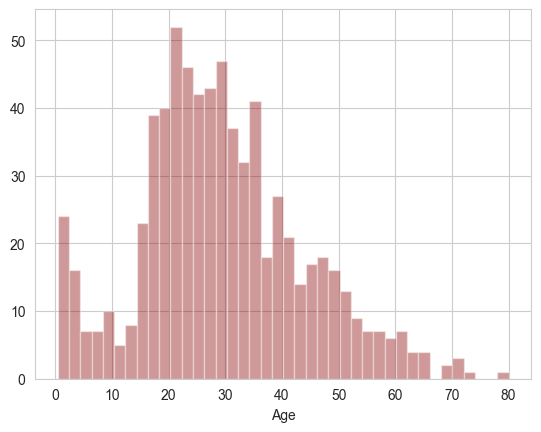

In [465]:
# .dropna() - removes all missing (NaN) values from the data.

sns.distplot(train['Age'].dropna(),kde= False,color='darkred',bins=40)

__Can use either plots__

<Axes: >

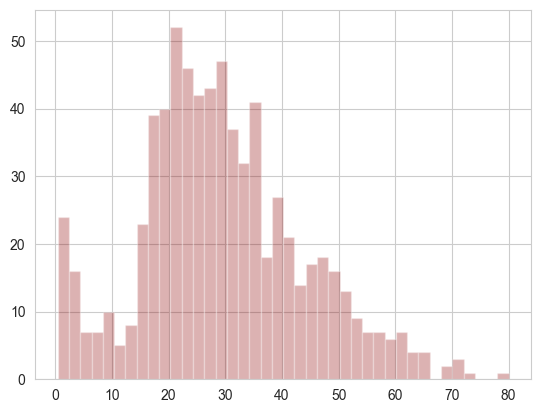

In [466]:
train['Age'].hist(bins=40,color='darkred',alpha=0.3)

/var/folders/cn/wdc06fpx6v17849rk031ksx00000gn/T/ipykernel_4828/2231004839.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train,x='SibSp',palette='rainbow')


<Axes: xlabel='SibSp', ylabel='count'>

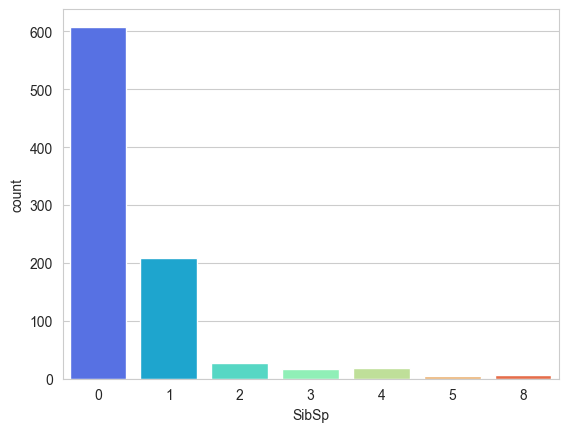

In [467]:
sns.countplot(data=train,x='SibSp',palette='rainbow')

<Axes: >

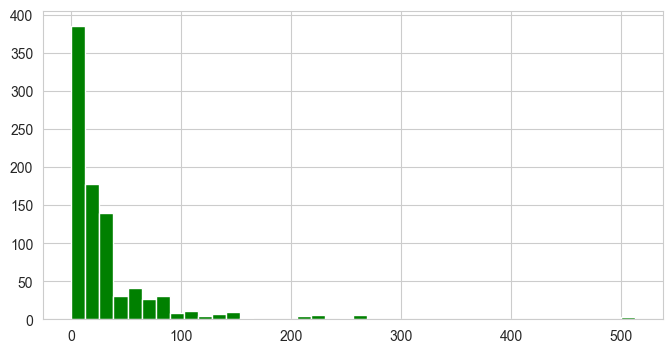

In [468]:
train["Fare"].hist(bins=40,color='green',figsize=(8,4))

__Data Cleaning__

We want to fill in missing age data instead or just dropping the missing age data rows. One way to do this is by filling in the mean age of all the passengers (imputation). However we can be smarter about this and check the average age by passenger class. For example:

/var/folders/cn/wdc06fpx6v17849rk031ksx00000gn/T/ipykernel_4828/4135693399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

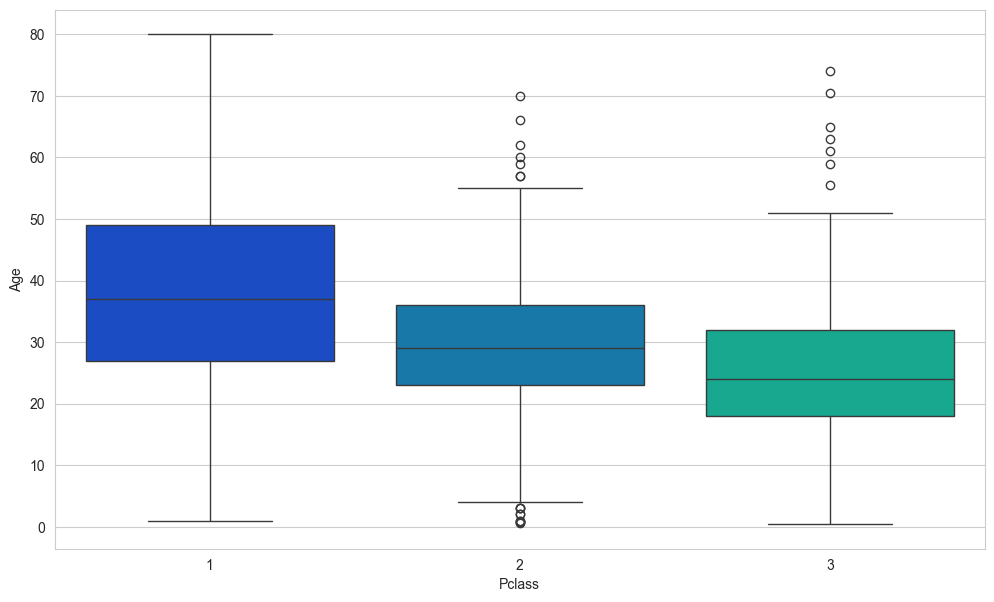

In [469]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')

We can see the wealthier passengers in the higher class tend to be older, which makes sense. We'll use these average age values to impute based on Pclass for Age.

In [470]:
# Impute means filling missing values with estimated values instead of deleting them.

def impute_age(cols):
    Age = cols['Age']
    Pclass = cols['Pclass']

    if pd.isnull(Age):
        if Pclass == 1:
            return 37

        elif Pclass == 2:
            return 29

        else:
            return 24
    else:
        return Age 

Now apply that function

In [471]:
# axis=0 → rows , axis=1 → columns
train[['Age','Pclass']].apply(impute_age,axis=1)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    24.0
889    26.0
890    32.0
Length: 891, dtype: float64

<Axes: >

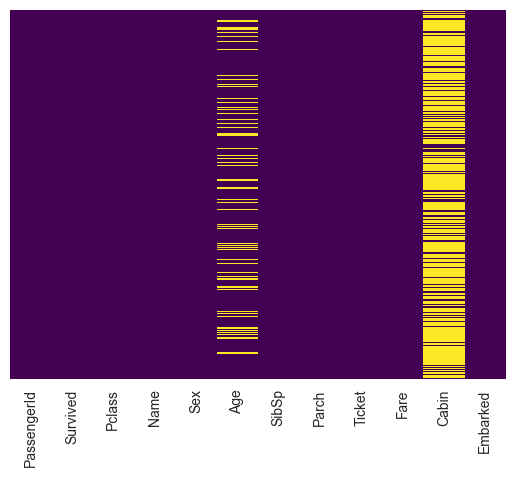

In [472]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

As of now droping the Cabin column

In [473]:
# inplace=True = Modify the original dataframe directly. if false it will create another temporary dataframe
train.drop('Cabin',axis=1,inplace=True)

In [474]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

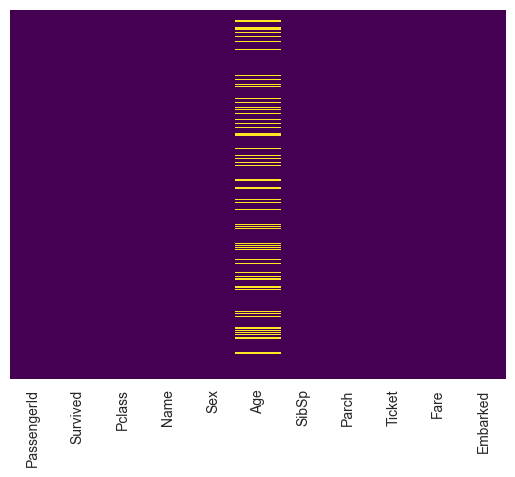

In [475]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

__Converting Categorial Features__

We'll need to convert categorial features to dummy variables using pandas! Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.

In [476]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


Machine Learning models cannot understand strings/text.

Models only understand numbers.

In [477]:
# In dataset (Embarked) = Port from where passenger boarded
# This preprocessing step converts text categories into numbers

pd.get_dummies(train['Embarked'],drop_first=True).head()
# We removed 1 line by drop_first=True To avoid:   ===== Dummy Variable Trap ===== Because columns become mathematically dependent. This can confuse regression models.

# pd.get_dummies() - “Convert categories into dummy columns.”
# if want 0-1 instead of True and False add code (dtype=int)

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


Sex Before - male,female
After get_dummies

male -

1  
 
0

Because: drop_first=True

removed female column.

In [478]:
sex = pd.get_dummies(train['Sex'],drop_first=True)
embark = pd.get_dummies(train['Embarked'],drop_first=True)

In [479]:
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

In [480]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [481]:
# concat = combine/join. 
# This adds new dummy columns into dataframe.

train = pd.concat([train,sex,embark],axis=1)

In [482]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


Here only survived is the dependent feature

Data ready for Model!

__Building a Logistic Regression model__

Let's start by splitting our data into a training set and test set.

__Train Test Split__

In [483]:
# dropping survived because it is a dependant feature

train.drop('Survived',axis=1).head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,3,22.0,1,0,7.2500,True,False,True
1,2,1,38.0,1,0,71.2833,False,False,False
2,3,3,26.0,0,0,7.9250,False,False,True
3,4,1,35.0,1,0,53.1000,False,False,True
4,5,3,35.0,0,0,8.0500,True,False,True


In [484]:
# output dataset

train['Survived'].head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [485]:
!pip install scikit-learn

In [486]:
from sklearn.model_selection import train_test_split

In [487]:
train.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
male             0
Q                0
S                0
dtype: int64

In [488]:
train.drop('Age', axis=1, inplace=True)

In [489]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1),
                                                    train['Survived'],test_size=0.30,
                                                    random_state=101)

__Training and Predicting__

In [490]:
from sklearn.linear_model import LogisticRegression

In [500]:
logmodel = LogisticRegression()

# .fit() means: "Train the model"
logmodel.fit(X_train,y_train)

/Users/manojkumar/Desktop/AI Study/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [501]:
prediction = logmodel.predict(X_test)

In [502]:
from sklearn.metrics import confusion_matrix

In [503]:
accuracy = confusion_matrix(y_test,prediction)

In [504]:
accuracy

array([[132,  22],
       [ 42,  72]])

In [505]:
from sklearn.metrics import accuracy_score

In [506]:
accuracy = accuracy_score(y_test, prediction)
accuracy

0.7611940298507462

In [507]:
prediction

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1])